# 217. Contains Duplicate
https://leetcode.com/problems/contains-duplicate/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Hash set | $O(n)$ | $O(n)$ | Optimal time |
| Sort then scan | $O(n \log n)$ | $O(1)$ | Optimal space |
| Brute force | $O(n^2)$ | $O(1)$ | Check all pairs |

## Methodology

Insert each element into a hash set. If an element is already in the set when we try to insert it, we found a duplicate. This gives O(n) time with O(n) space.

## Solutions

### C#

In [ ]:
public class Solution {
    public bool ContainsDuplicate(int[] nums) {
        var seen = new HashSet<int>();
        foreach (int num in nums) {
            if (!seen.Add(num))
                return true;
        }
        return false;
    }
}

### Python

In [ ]:
class Solution:
    def containsDuplicate(self, nums: list[int]) -> bool:
        return len(nums) != len(set(nums))

### Go

In [ ]:
func containsDuplicate(nums []int) bool {
    seen := make(map[int]bool)
    for _, num := range nums {
        if seen[num] {
            return true
        }
        seen[num] = true
    }
    return false
}

### Rust

In [ ]:
use std::collections::HashSet;

impl Solution {
    pub fn contains_duplicate(nums: Vec<i32>) -> bool {
        let mut seen = HashSet::new();
        for num in nums {
            if !seen.insert(num) {
                return true;
            }
        }
        false
    }
}

## Example Scenarios

### 1. Common Case — Duplicate Found Mid-Array
**Input:** `nums = [1, 2, 3, 1]`

Insert 1, 2, 3 into the set. When we try to insert 1 again, it already exists. Return true immediately without checking the rest. Early termination saves time.

WHY it's tricky: It isn't — validates basic hash set insertion and duplicate detection.

$n = 4, \text{ checked 4 elements. } O(n) = O(4). \text{ Set size at detection: } 3$

### 2. Slightly Complex — No Duplicates, Full Scan Required
**Input:** `nums = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]`

All elements are unique. The set grows to hold all 10 elements. Must iterate through the entire array before concluding false. No early termination possible for "no duplicate" answers.

WHY it's tricky: To return false, we must process every element. The Python one-liner `len(nums) != len(set(nums))` is elegant but builds the entire set upfront. The iterative approach can short-circuit on true but not on false.

$n = 10. \text{ All unique} \Rightarrow \text{full scan. } O(n) \text{ time, } O(n) \text{ space.}$

### 3. Edge Case: Time Factor — 10^5 Elements, Duplicate at End
**Input:** `nums = [1, 2, 3, ..., 99999, 1]` (100,000 elements)

Elements 1 through 99,999 are unique. The last element duplicates 1. We must insert 99,999 elements before detecting the duplicate at position 99,999. Worst case for time when duplicates exist.

WHY it's tricky: 99,999 successful insertions (O(1) amortized each) before finding the duplicate. Hash table resizing occurs multiple times during growth, with amortized cost hidden in the O(1) guarantee.

$n = 10^5. \text{ Insertions before detection: } n - 1 = 99{,}999. \text{ Hash rehashes:} \sim \log(n) \text{ times.}$

### 4. Edge Case: Space Factor — All Unique, Maximum Set Size
**Input:** `nums = [1, 2, 3, ..., 100000]` (10^5 distinct elements)

No duplicates, so the hash set grows to hold all 100,000 elements. Hash table allocates ~150K slots (load factor 2/3). Total memory: several MB.

WHY it's tricky: O(n) space is unavoidable with hash set. The sort-then-scan alternative uses O(1) extra space (in-place sort) at O(n log n) time. For memory-constrained environments, sorting may be preferred.

$\text{Space} = O(n) = O(10^5). \text{ Alternative: sort in } O(n \log n) \text{ with } O(1) \text{ space.}$

### 5. Almost-Impossible — 10^5 Elements at INT Boundaries
**Input:** `nums = [-10^9, -10^9+1, ..., -10^9+99998, -10^9]` (100,000 elements)

Values range near $-10^9$, with $-10^9$ duplicated at the end. Hash functions must handle large negatives correctly. In 32-bit signed integers, $|-10^9| < 2.1 \times 10^9$ fits comfortably.

WHY it's tricky: Large negative values can cause issues with hash functions using modular arithmetic. Also, an array-based approach would need $2 \times 10^9$ slots — impossible. The hash set handles any value range in O(n).

$\text{Value range: } 2 \times 10^9. \text{ Array approach: impossible. Hash set: } O(n) = O(10^5) \text{ regardless.}$


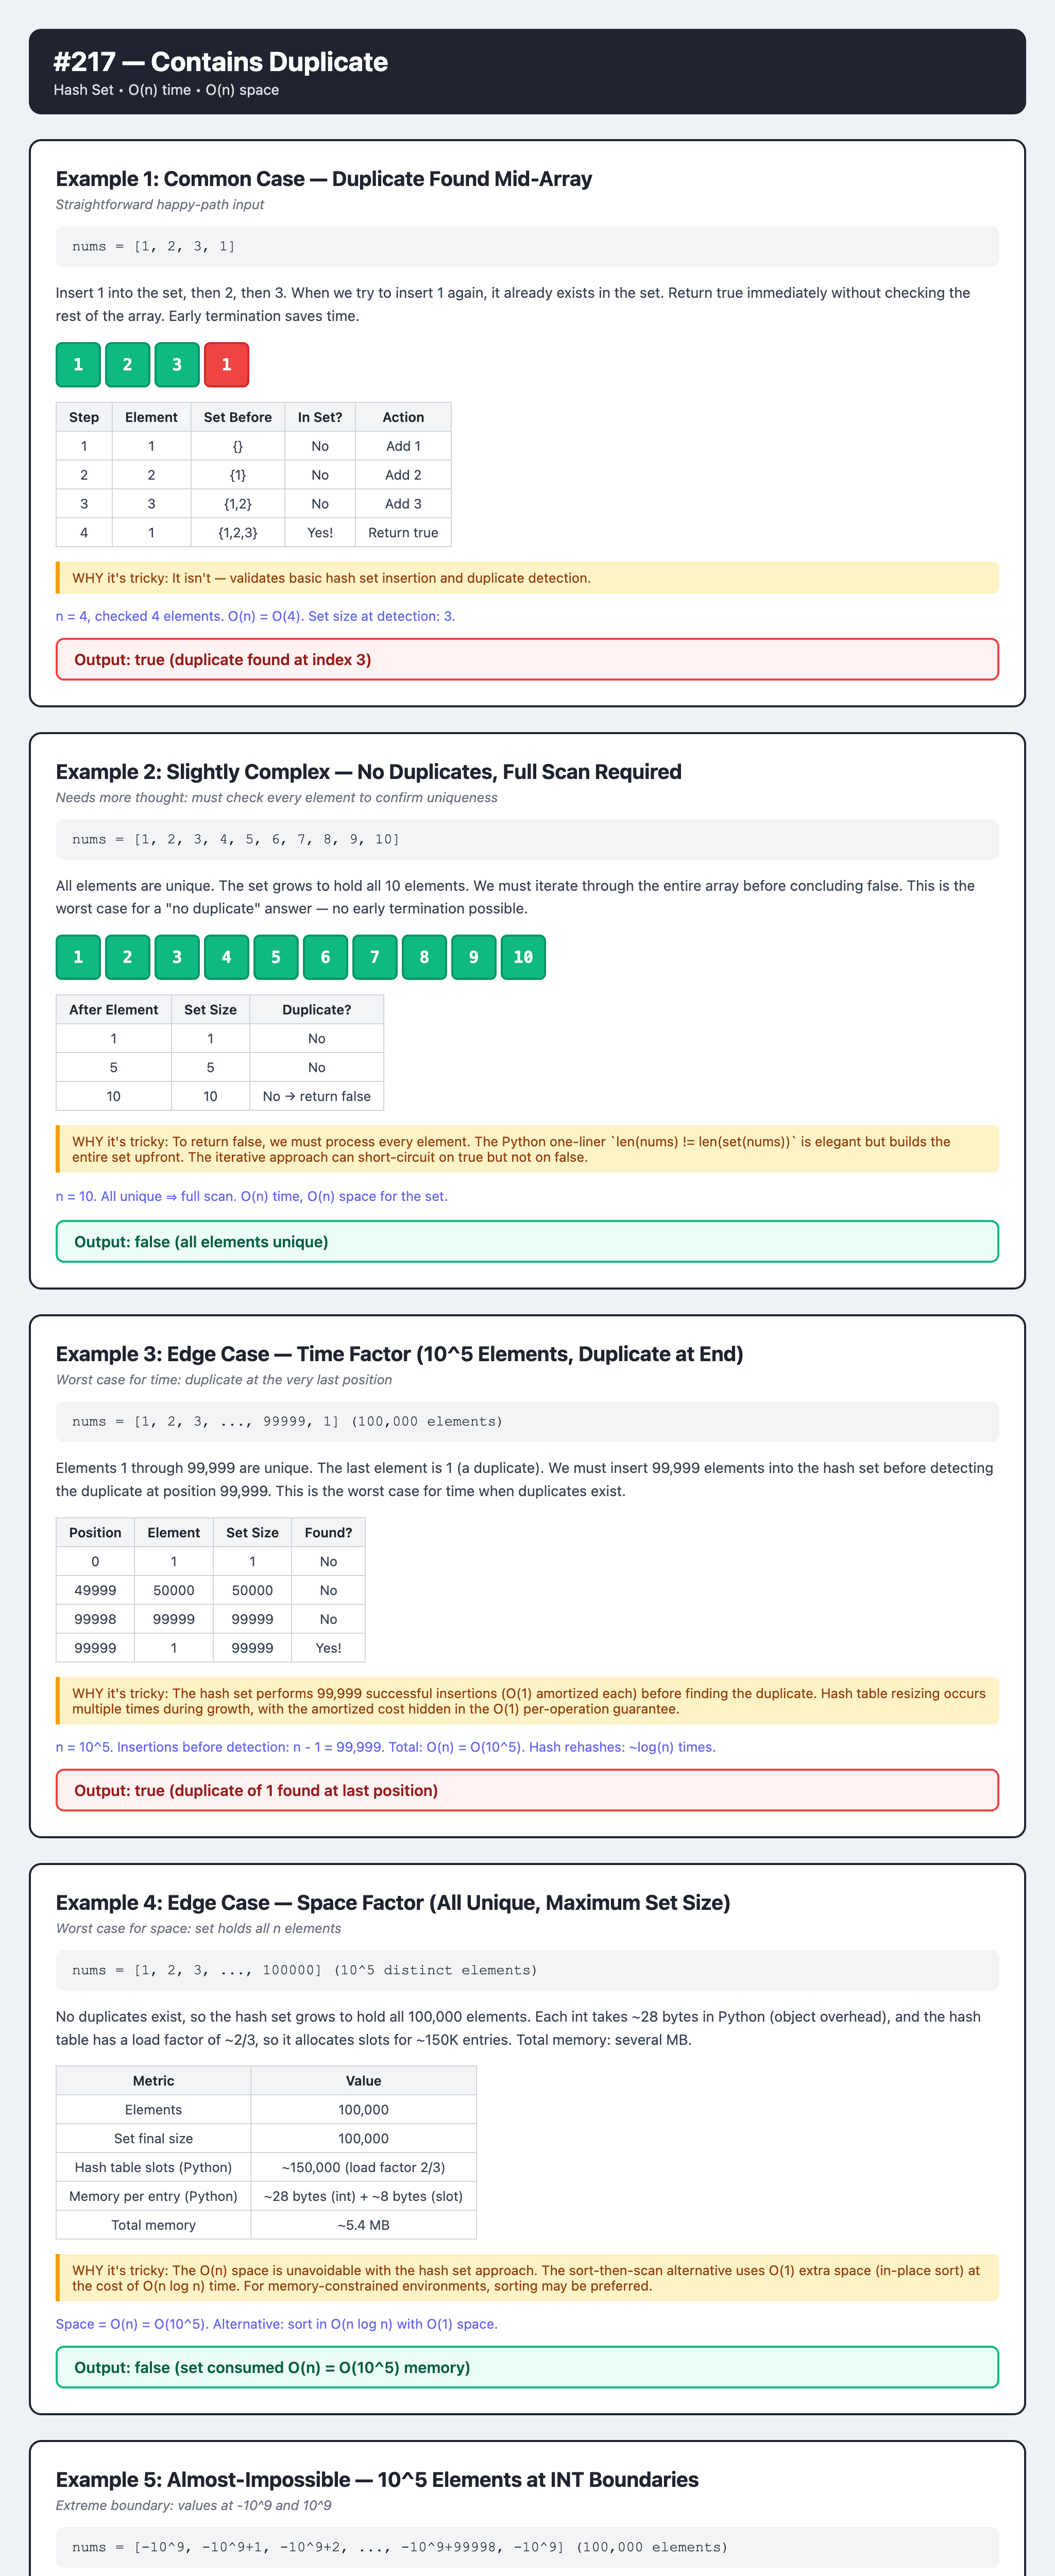